In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, fbeta_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
import os
import glob
import joblib

warnings.filterwarnings('ignore')


pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

### 1. Loading & Merging Data...

In [10]:
# --- A. DEFINISI PATH ---
# 1. Cari File Raw Ultimate Terbaru (Broker + Asing + Komposisi)
list_of_files = glob.glob('data/raw/90d/foreign_1769222915.xlsx')
if list_of_files:
    PATH_RAW_ULTIMATE = max(list_of_files, key=os.path.getctime)
    print(f"Menggunakan Raw Ultimate: {os.path.basename(PATH_RAW_ULTIMATE)}")
else:
    print("File ULTIMATE_DATASET tidak ditemukan di data/raw/90d/!")
    exit()

# 2. Path Data Lainnya
PATH_RAW_DAILY = 'data/raw/90d/inventory_ts_1769221926.xlsx'
PATH_RAW_SH = 'data/raw/90d/shareholder_1769221926.xlsx'

# 3. Path Data COLLECTED (Hasil Predict.py)
PATH_COL_DAILY = 'data/collected/inventory_collected.xlsx'
PATH_COL_ULTIMATE = 'data/collected/foreign_collected.xlsx'
PATH_COL_SH = 'data/collected/shareholder_collected.xlsx'

# --- B. FUNGSI LOAD GENERIC ---
def load_and_merge(path_raw, path_collected, subset_dupe, name="Data"):
    # 1. Load Raw
    try:
        df_main = pd.read_excel(path_raw)
        df_main.columns = df_main.columns.str.lower().str.strip()
    except Exception:
        df_main = pd.DataFrame()

    # 2. Load Collected & Merge
    if os.path.exists(path_collected):
        try:
            df_col = pd.read_excel(path_collected)
            if not df_col.empty:
                df_col.columns = df_col.columns.str.lower().str.strip()
                # Gabung
                df_main = pd.concat([df_main, df_col], ignore_index=True)
                # Hapus Duplikat (Keep Last = Prioritas Data Collected/Terbaru)
                df_main = df_main.drop_duplicates(subset=subset_dupe, keep='last')
                print(f"   -> {name}: Raw + Collected merged. Total: {len(df_main)}")
                return df_main
        except Exception as e:
            print(f"Error Load Collected {name}: {e}")
    
    print(f"   -> {name}: Raw only ({len(df_main)} records)")
    return df_main

# --- C. EKSEKUSI LOAD ---

# 1. Load Ultimate Profile (Static Data: Broker/Asing/Comp)
print("\nMemproses Data Ultimate Profile...")
df_ultimate = load_and_merge(PATH_RAW_ULTIMATE, PATH_COL_ULTIMATE, subset_dupe=['ticker'], name="Ultimate Profile")

# 2. Load Inventory (Time Series: Harga/Vol)
print("\nMemproses Data Harian...")
df_daily = load_and_merge(PATH_RAW_DAILY, PATH_COL_DAILY, subset_dupe=['ticker', 'date'], name="Inventory")
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')

# 3. Load Shareholder History (Time Series Bulanan)
print("\nMemproses Shareholder History...")
df_sh = load_and_merge(PATH_RAW_SH, PATH_COL_SH, subset_dupe=['ticker', 'date'], name="Shareholder")
if not df_sh.empty:
    df_sh['date'] = pd.to_datetime(df_sh['date'])
    df_sh = df_sh.sort_values(['ticker', 'date'])
    # Hitung perubahan bulanan (MoM)
    df_sh['sh_change_mom'] = df_sh.groupby('ticker')['value'].pct_change()

# --- D. MERGING STRATEGY (ULTIMATE LOGIC) ---
print("\nMenggabungkan Semua Dimensi Data...")
raw_df = pd.DataFrame()

unique_tickers = df_daily['ticker'].unique()
for ticker in unique_tickers:
    d_data = df_daily[df_daily['ticker'] == ticker].copy()
    s_data = df_sh[df_sh['ticker'] == ticker].copy() if not df_sh.empty else pd.DataFrame()
    
    if d_data.empty: continue
    
    # 1. Merge Time Series (Harga + Shareholder History)
    if s_data.empty:
        merged = d_data
        merged['sh_change_mom'] = 0
    else:
        # Merge Backward: Harga tgl 15 Jan akan mengambil Data SH tgl 30 Des (terakhir rilis)
        merged = pd.merge_asof(d_data, s_data, on='date', direction='backward', suffixes=('', '_monthly'))
    
    raw_df = pd.concat([raw_df, merged])

# 2. Merge Static Profile (Ultimate Data)
print("Menempelkan Profil Ultimate ke Data Harian...")

cols_ultimate = [
    'ticker', 
    'top_buyer_avg', 'top_buyer_code',
    'foreign_net_vol', 'foreign_pct', 
    'public_pct', 'controller_pct'     
]

# Filter kolom yg tersedia saja (untuk safety)
available_cols = [c for c in cols_ultimate if c in df_ultimate.columns]
raw_df = pd.merge(raw_df, df_ultimate[available_cols], on='ticker', how='left')

# Handling Missing Values (Penting untuk saham baru/data kosong)
raw_df['foreign_pct'] = raw_df['foreign_pct'].fillna(0)
raw_df['public_pct'] = raw_df['public_pct'].fillna(0)
raw_df['controller_pct'] = raw_df['controller_pct'].fillna(0)
raw_df['top_buyer_avg'] = raw_df['top_buyer_avg'].fillna(0)

# Encode Broker Code
le_broker = LabelEncoder()
raw_df['top_buyer_code'] = raw_df['top_buyer_code'].fillna('UNKNOWN').astype(str)
raw_df['broker_id'] = le_broker.fit_transform(raw_df['top_buyer_code'])

print(f"\nDimensi Final: {raw_df.shape}")

Menggunakan Raw Ultimate: foreign_1769222915.xlsx

Memproses Data Ultimate Profile...
   -> Ultimate Profile: Raw + Collected merged. Total: 316

Memproses Data Harian...
   -> Inventory: Raw + Collected merged. Total: 21473

Memproses Shareholder History...
   -> Shareholder: Raw + Collected merged. Total: 11012

Menggabungkan Semua Dimensi Data...
Menempelkan Profil Ultimate ke Data Harian...

Dimensi Final: (21473, 18)


### 2. FEATURE ENGINEERING

In [ ]:
print('Feature Engineering')

raw_df = raw_df.sort_values(['ticker', 'date'])

# --- A. Fitur Dasar & Bandarmology ---
raw_df['dist_to_bandar'] = (raw_df['close'] - raw_df['top_buyer_avg']) / (raw_df['top_buyer_avg'] + 1e-5)
raw_df['net_vol_ratio'] = raw_df['net_vol'] / (raw_df['volume'] + 1e-5)

# --- B. Fitur Baru: Foreign & Structure Intelligence ---
# 1. Foreign Dominance (Saham Asing)
raw_df['is_foreign_stock'] = np.where(raw_df['foreign_pct'] > 0.2, 1, 0)

# 2. Float Risk (Risiko Likuiditas)
# < 5% (Terlalu kering/Gembok), > 80% (Terlalu berat/Ritel nyangkut)
raw_df['float_risk'] = np.where((raw_df['public_pct'] < 0.05) | (raw_df['public_pct'] > 0.80), 1, 0)

# 3. Controller Power
raw_df['strong_controller'] = np.where(raw_df['controller_pct'] > 0.5, 1, 0)

# --- C. Technical Indicators ---
raw_df['ma_20'] = raw_df.groupby('ticker')['close'].transform(lambda x: x.rolling(20).mean())
raw_df['volatility_5d'] = raw_df.groupby('ticker')['close'].transform(lambda x: x.rolling(5).std())
raw_df['net_vol_5d_sum'] = raw_df.groupby('ticker')['net_vol'].transform(lambda x: x.rolling(5).sum())



def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    return 100 - (100 / (1 + gain/(loss+1e-5)))

raw_df['rsi_14'] = raw_df.groupby('ticker')['close'].transform(lambda x: calculate_rsi(x))

# --- D. Retail Panic & Target ---
raw_df['is_retail_panic'] = np.where((raw_df['sh_change_mom'] < -0.01) & (raw_df['close'] < raw_df['ma_20']), 1, 0)

# Target: Profit > 5% dalam 10 hari
raw_df['future_close'] = raw_df.groupby('ticker')['close'].shift(-10)
raw_df['return_10d'] = (raw_df['future_close'] - raw_df['close']) / raw_df['close']
raw_df['TARGET'] = np.where(raw_df['return_10d'] > 0.05, 1, 0)

# Cleanup
raw_df.dropna(inplace=True)
raw_df.to_excel("data/processed/final_data.xlsx")

# Split Data
cutoff_idx = int(len(raw_df) * 0.8)
df_train = raw_df.iloc[:cutoff_idx]
df_test = raw_df.iloc[cutoff_idx:]

print(f"   Data Train: {len(df_train)} | Data Test: {len(df_test)}")

Feature Engineering
   Data Train: 9847 | Data Test: 2462


### 3. TRAINING HYBRID (LGBM + RF + CATBOOST)

In [12]:
features = [
    'net_vol', 'sh_change_mom', 'dist_to_bandar', 'rsi_14', 
    'net_vol_5d_sum', 'is_retail_panic', 'broker_id', 
    'net_vol_ratio', 'volatility_5d',
    'foreign_pct', 'is_foreign_stock', 'float_risk', 'strong_controller' # Fitur Baru
]

X = df_train[features].values
y = df_train['TARGET'].values
X_test_val = df_test[features].values
y_test_real = df_test['TARGET'].values

# Handle Imbalance
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Array Penampung Prediksi
oof_lgb, oof_rf, oof_cat = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))
test_lgb, test_rf, test_cat = np.zeros(len(X_test_val)), np.zeros(len(X_test_val)), np.zeros(len(X_test_val))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y), 1):
    X_tr, y_tr = X[tr_idx], y[tr_idx]
    X_va, y_va = X[va_idx], y[va_idx]
    
    # 1. LightGBM
    lgb_train = lgb.Dataset(X_tr, y_tr)
    lgb_val = lgb.Dataset(X_va, y_va, reference=lgb_train)
    model_lgb = lgb.train(
        {'objective':'binary', 'metric':'auc', 'learning_rate':0.05, 'max_depth':-1, 
         'num_leaves':31, 'scale_pos_weight':scale_pos_weight, 'verbose':-1, 'random_state':42},
        lgb_train, num_boost_round=1000, valid_sets=[lgb_val], 
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    oof_lgb[va_idx] = model_lgb.predict(X_va)
    test_lgb += model_lgb.predict(X_test_val) / 5
    
    # 2. Random Forest
    model_rf = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42
    )
    model_rf.fit(X_tr, y_tr)
    oof_rf[va_idx] = model_rf.predict_proba(X_va)[:, 1]
    test_rf += model_rf.predict_proba(X_test_val)[:, 1] / 5
    
    # 3. CatBoost
    model_cat = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6, 
        scale_pos_weight=scale_pos_weight, verbose=0, random_state=42,
        eval_metric='AUC', allow_writing_files=False
    )
    model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
    oof_cat[va_idx] = model_cat.predict_proba(X_va)[:, 1]
    test_cat += model_cat.predict_proba(X_test_val)[:, 1] / 5
    
    print(f"   Fold {fold}/5 Selesai.")

   Fold 1/5 Selesai.
   Fold 2/5 Selesai.
   Fold 3/5 Selesai.
   Fold 4/5 Selesai.
   Fold 5/5 Selesai.


### 4. BLENDING & OPTIMIZATION

In [13]:
# Bobot Hybrid
w_lgb, w_rf, w_cat = 0.4, 0.3, 0.3
oof_blend = (w_lgb * oof_lgb) + (w_rf * oof_rf) + (w_cat * oof_cat)

best_thr = 0.60
best_score = 0
thresholds = np.arange(0.5, 0.90, 0.01)

for thr in thresholds:
    pred_bin = (oof_blend > thr).astype(int)
    if pred_bin.sum() > 50:
        score = fbeta_score(y, pred_bin, beta=0.5, zero_division=0)
        if score > best_score:
            best_score = score
            best_thr = thr

print(f"   Threshold Optimal: {best_thr:.3f} | F0.5 Score: {best_score:.4f}")

   Threshold Optimal: 0.620 | F0.5 Score: 0.7950


### 5. EVALUASI AKHIR (BACKTEST)

In [14]:
test_blend_prob = (w_lgb * test_lgb) + (w_rf * test_rf) + (w_cat * test_cat)

if (test_blend_prob > best_thr).sum() == 0:
    print("Threshold terlalu ketat, menurunkan ke 0.65 untuk Backtest.")
    best_thr = 0.65

test_pred_final = (test_blend_prob > best_thr).astype(int)
df_test['model_signal'] = test_pred_final
df_test['model_prob'] = test_blend_prob

# Statistik
num_trades = df_test['model_signal'].sum()
avg_ret_market = df_test['return_10d'].mean()
avg_ret_model = df_test[df_test['model_signal'] == 1]['return_10d'].mean() if num_trades > 0 else 0

print("\n" + "="*50)
print("📊 HASIL BACKTEST (MODEL V3)")
print("="*50)
print(classification_report(y_test_real, test_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test_real, test_pred_final)
tn, fp, fn, tp = cm.ravel()
precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"Total Sinyal BUY             : {num_trades} saham")
print(f"True Positive (Cuan)      : {tp}")
print(f"False Positive (Boncos)   : {fp}")
print(f"Real Precision            : {precision_manual:.2%}")
print("-" * 30)
print(f"Rata-rata Return Pasar       : {avg_ret_market*100:.2f}%")
print(f"Rata-rata Return Model       : {avg_ret_model*100:.2f}%")
print(f"EDGE (Keunggulan)         : +{(avg_ret_model - avg_ret_market)*100:.2f}%")
print("="*50)


📊 HASIL BACKTEST (MODEL V3)
              precision    recall  f1-score   support

           0       0.77      0.93      0.84      1803
           1       0.56      0.25      0.34       659

    accuracy                           0.75      2462
   macro avg       0.67      0.59      0.59      2462
weighted avg       0.72      0.75      0.71      2462

Total Sinyal BUY             : 288 saham
True Positive (Cuan)      : 162
False Positive (Boncos)   : 126
Real Precision            : 56.25%
------------------------------
Rata-rata Return Pasar       : 3.09%
Rata-rata Return Model       : 13.45%
EDGE (Keunggulan)         : +10.36%


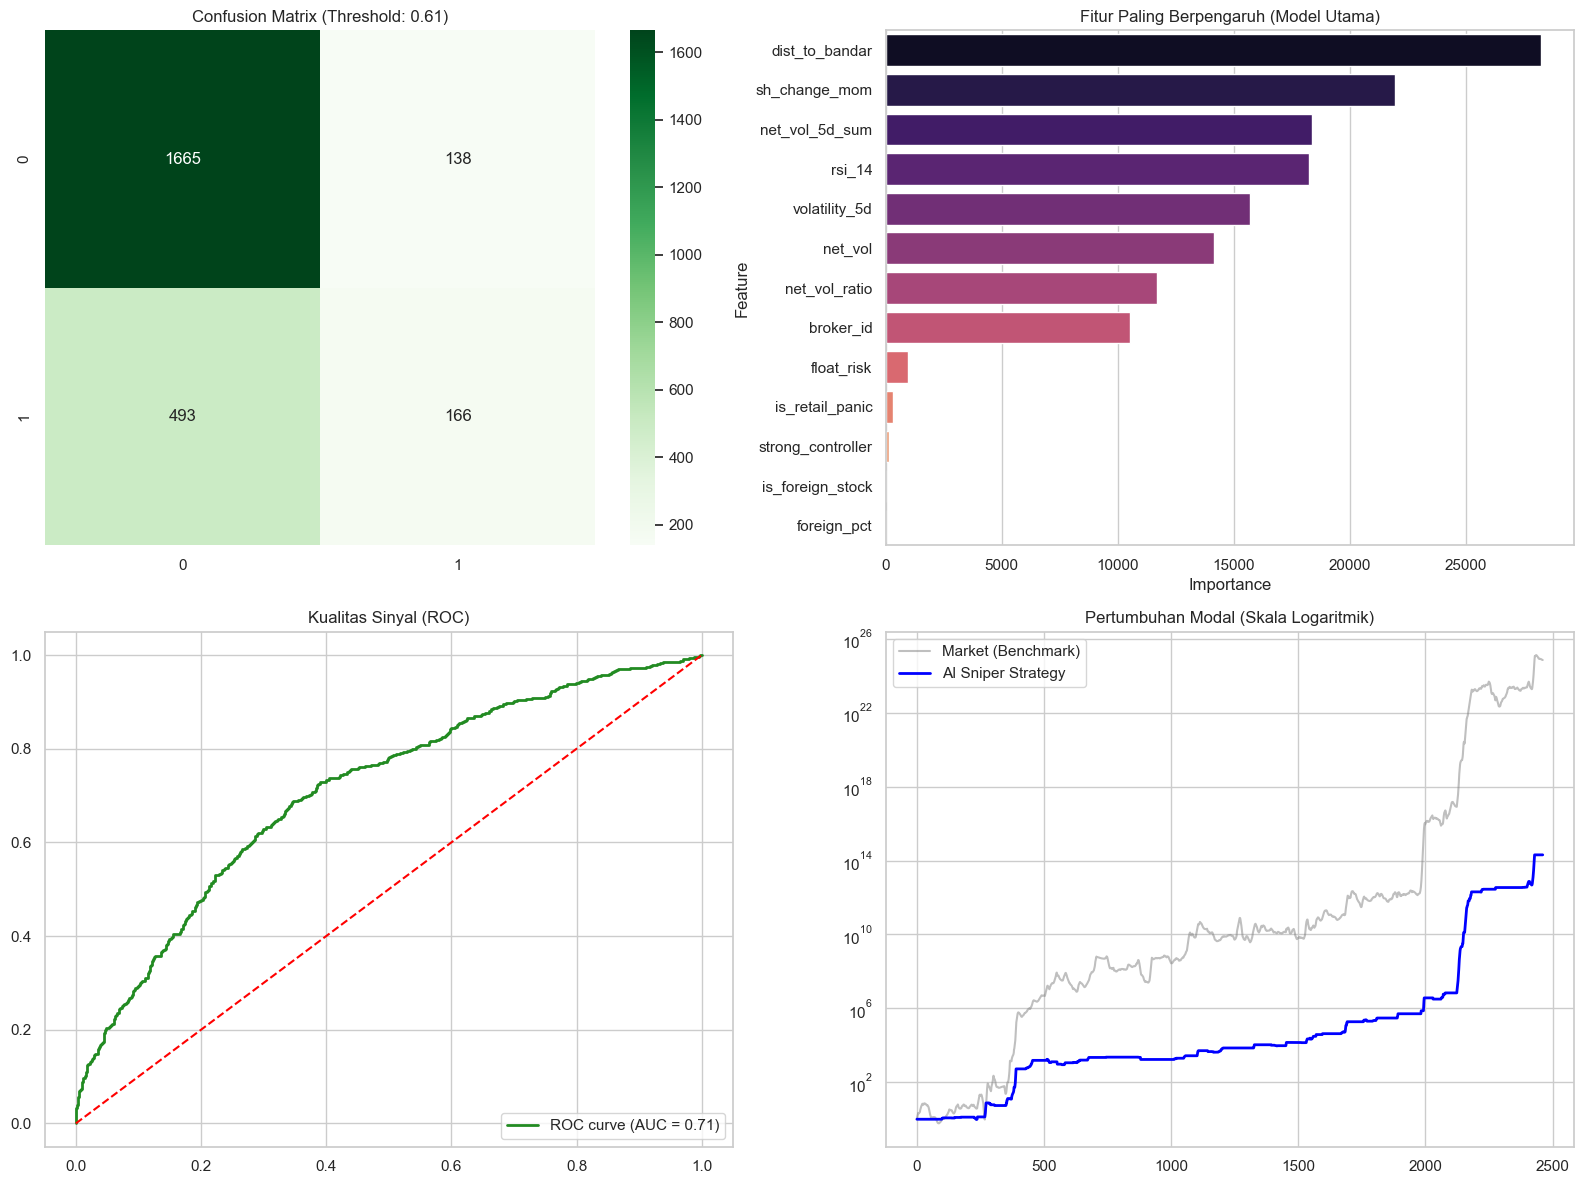

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def visualize_performance(y_true, y_prob, features_list, model_lgb, df_test, current_thr=0.61):
    
    if not os.path.exists('plots'): os.makedirs('plots')
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. CONFUSION MATRIX (Realitas Prediksi)
    y_pred = (y_prob > current_thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 0])
    axes[0, 0].set_title(f'Confusion Matrix (Threshold: {current_thr})')

    # 2. FEATURE IMPORTANCE (Analisis Bandarmology)
    importance_df = pd.DataFrame({
        'Feature': features_list,
        'Importance': model_lgb.feature_importance(importance_type='gain')
    }).sort_values(by='Importance', ascending=False)
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma', ax=axes[0, 1])
    axes[0, 1].set_title('Fitur Paling Berpengaruh (Model Utama)')

    # 3. ROC CURVE
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1, 0].plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[1, 0].plot([0, 1], [0, 1], color='red', linestyle='--')
    axes[1, 0].set_title('Kualitas Sinyal (ROC)')
    axes[1, 0].legend(loc="lower right")

    # 4. EQUITY CURVE (ANTI-DISTORSI)
    df_plot = df_test.copy()
    df_plot['ret_clean'] = df_plot['return_10d'].clip(lower=-0.5, upper=1.0)
    df_plot['strat_ret'] = np.where(y_prob > current_thr, df_plot['ret_clean'], 0)
    
    cum_market = (1 + df_plot['ret_clean']).cumprod()
    cum_strategy = (1 + df_plot['strat_ret']).cumprod()
    
    axes[1, 1].plot(cum_market.values, label='Market (Benchmark)', color='gray', alpha=0.5)
    axes[1, 1].plot(cum_strategy.values, label='AI Sniper Strategy', color='blue', lw=2)
    axes[1, 1].set_title('Pertumbuhan Modal (Skala Logaritmik)')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('plots/model_performance_final.png')

visualize_performance(y_test_real, test_blend_prob, features, model_lgb, df_test)

### SIMPAN MODEL KE FILE (JOBLIB)

In [16]:
import joblib
import os

model_package = {
    'model_lgb': model_lgb,
    'model_rf': model_rf,
    'model_cat': model_cat,
    'encoder': le_broker,      
    'features': features,    
    'threshold': best_thr,     
    'config': {
        'w_lgb': 0.4,
        'w_rf': 0.3, 
        'w_cat': 0.3
    }
}

if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(model_package, 'models/model_v3_hybrid.pkl')
print("Model berhasil disimpan di: models/model_v3_hybrid.pkl")

Model berhasil disimpan di: models/model_v3_hybrid.pkl
